# Imports

In [5]:
# !pip install kagglehub
# !pip install opencv-python
# !pip install matplotlib
# !pip install pandas
# !pip install scikit-learn
# !pip install tensorflow

In [6]:
import kagglehub
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import json
import pandas as pd
import random
import keras
from keras import layers
from keras import ops
from keras.layers import Conv2D, AvgPool2D, MaxPool2D, Dropout, Input, Flatten, Dense, GlobalAveragePooling2D
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
save_folder = Path("/content/drive/MyDrive/Resistors")
save_folder.mkdir(parents=True, exist_ok=True)

# Load in data

In [9]:
path = Path(kagglehub.dataset_download("barrettotte/resistors"))

Using Colab cache for faster access to the 'resistors' dataset.


In [10]:
os.listdir(path)

['4-band', 'README.md', '5-band', 'train.csv']

## Load in CSV

In [11]:
df = pd.read_csv(path / "train.csv")
df

,image,band_count,ohms,tolerance,watts,bands
0,4-band\4B-100K-T5\4B-100K-T5-1.jpg,4,100000.0,0.05,0.25,brown black yellow gold
1,4-band\4B-100K-T5\4B-100K-T5-10.jpg,4,100000.0,0.05,0.25,brown black yellow gold
2,4-band\4B-100K-T5\4B-100K-T5-2.jpg,4,100000.0,0.05,0.25,brown black yellow gold
3,4-band\4B-100K-T5\4B-100K-T5-3.jpg,4,100000.0,0.05,0.25,brown black yellow gold
4,4-band\4B-100K-T5\4B-100K-T5-4.jpg,4,100000.0,0.05,0.25,brown black yellow gold
...,...,...,...,...,...,...
1265,5-band\5B-9K1-T1\5B-9K1-T1-5.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1266,5-band\5B-9K1-T1\5B-9K1-T1-6.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1267,5-band\5B-9K1-T1\5B-9K1-T1-7.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1268,5-band\5B-9K1-T1\5B-9K1-T1-8.jpg,5,9100.0,0.01,0.25,white brown black brown brown


## Load in 4 band data

In [12]:
with open(path / "4-band" / "4-band.json", "r") as file:
    four_band_json = json.load(file)

In [13]:
four_band_images = []

for folder in os.listdir(path / "4-band"):
    if ".json" in folder:
      continue
    for image in os.listdir(path / "4-band" / folder):
        current_image = cv2.imread((path / "4-band" / folder / image), cv2.IMREAD_COLOR_RGB)
        index = df[df["image"].str.contains(fr"4-band\{folder}\{image}", regex=False)].index[0]
        four_band_images.append((index, current_image))

JSON

In [14]:
print(json.dumps(four_band_json, indent=4))

{
    "1": [
        "black",
        "brown",
        "black",
        "gold"
    ],
    "1.2": [
        "brown",
        "red",
        "gold",
        "gold"
    ],
    "1.5": [
        "brown",
        "green",
        "gold",
        "gold"
    ],
    "1.8": [
        "brown",
        "grey",
        "gold",
        "gold"
    ],
    "2.2": [
        "red",
        "red",
        "gold",
        "gold"
    ],
    "2.7": [
        "red",
        "violet",
        "gold",
        "gold"
    ],
    "3.3": [
        "orange",
        "orange",
        "gold",
        "gold"
    ],
    "3.9": [
        "orange",
        "white",
        "gold",
        "gold"
    ],
    "4.3": [
        "yellow",
        "orange",
        "gold",
        "gold"
    ],
    "4.7": [
        "yellow",
        "violet",
        "gold",
        "gold"
    ],
    "5.1": [
        "green",
        "brown",
        "gold",
        "gold"
    ],
    "5.6": [
        "green",
        "blue",
        "gold",
   

Example image

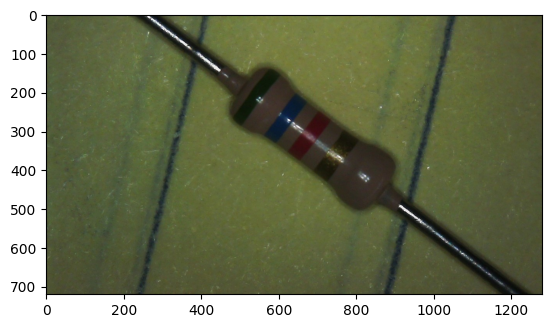

In [15]:
plt.imshow(four_band_images[10][1])

## Load in 5 band data

In [16]:
with open(path / "5-band" / "5-band.json", "r") as file:
    five_band_json = json.load(file)

In [17]:
five_band_images = []

for folder in os.listdir(path / "5-band"):
    if ".json" in folder:
        continue
    for image in os.listdir(path / "5-band" / folder):
        current_image = cv2.imread((path / "5-band" / folder / image), cv2.IMREAD_COLOR_RGB)
        index = df[df["image"].str.contains(fr"5-band\{folder}\{image}", regex=False)].index[0]
        five_band_images.append((index, current_image))

JSON

In [18]:
print(json.dumps(five_band_json, indent=4))

{
    "1": [
        "brown",
        "black",
        "black",
        "silver",
        "brown"
    ],
    "1.5": [
        "brown",
        "green",
        "black",
        "silver",
        "brown"
    ],
    "2.2": [
        "red",
        "red",
        "black",
        "silver",
        "brown"
    ],
    "3.3": [
        "orange",
        "orange",
        "black",
        "silver",
        "brown"
    ],
    "4.7": [
        "yellow",
        "violet",
        "black",
        "silver",
        "brown"
    ],
    "5.1": [
        "green",
        "brown",
        "black",
        "silver",
        "brown"
    ],
    "10": [
        "brown",
        "black",
        "black",
        "gold",
        "brown"
    ],
    "20": [
        "red",
        "black",
        "black",
        "gold",
        "brown"
    ],
    "22": [
        "red",
        "red",
        "black",
        "gold",
        "brown"
    ],
    "33": [
        "orange",
        "orange",
        "black",
     

Example image

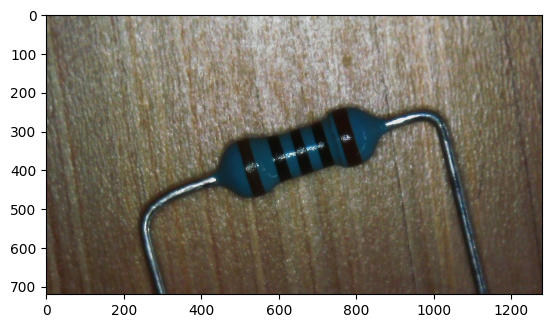

In [19]:
plt.imshow(five_band_images[10][1])

# Data split

In [20]:
merged_image_list = four_band_images + five_band_images
random.shuffle(merged_image_list)

In [21]:
indices_list, image_list = map(list, zip(*merged_image_list))

In [22]:
for i, image in enumerate(image_list):
    resized_image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_LINEAR)
    scaled_image = resized_image.astype(np.float32) / 255.0
    image_list[i] = scaled_image

## Train Test Split

In [23]:
size = len(image_list)
train_size = int(0.8 * size)

train_images = image_list[:train_size]
train_indices = indices_list[:train_size]
train_labels = df.loc[train_indices, "ohms"].values

test_images = image_list[train_size:]
test_indices = indices_list[train_size:]
test_labels = df.loc[test_indices, "ohms"].values

## MinMax Scaling

In [24]:
train_labels_log = np.log10(train_labels)
test_labels_log = np.log10(test_labels)

train_labels_log = train_labels_log.reshape(-1, 1)
test_labels_log = test_labels_log.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))

train_labels_scaled = scaler.fit_transform(train_labels_log)
test_labels_scaled = scaler.transform(test_labels_log)

In [25]:
train_images = np.array(train_images)
test_images = np.array(test_images)

# Data analysis

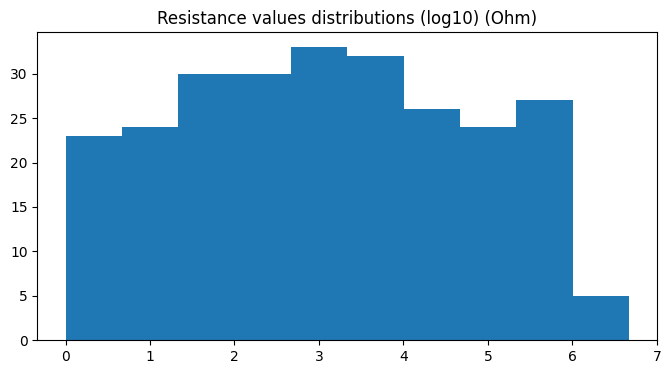

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(test_labels_log)
plt.title("Resistance values distributions (log10) (Ohm)")
plt.show()

# Models

In [27]:
data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ])

In [28]:
def create_base_model():
    base_model = keras.Sequential([
        Input((224, 224, 3)),

        Conv2D(32, (3, 3), activation="relu"),
        AvgPool2D((2, 2), 1),
        Dropout(0.15),

        Conv2D(64, (5, 5), activation="relu"),
        AvgPool2D((2, 2), 1),
        Dropout(0.15),

        Conv2D(64, (3, 3), activation="relu"),
        AvgPool2D((2, 2), 1),
        Dropout(0.15),

        Flatten(),
        Dense(1)
    ])

    base_model.compile(optimizer="Adam", loss="mse", metrics=["mae"])

    return base_model

In [29]:
def create_data_augmentation_model():
    data_augmentation_model = keras.Sequential([
        Input((224, 224, 3)),
        data_augmentation,

        Conv2D(32, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),


        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    data_augmentation_model.compile(optimizer="Adam", loss=tf.keras.losses.Huber(), metrics=["mae"])

    return data_augmentation_model

In [30]:
def create_deeper_dense_model():
    deeper_dense_model = keras.Sequential([
        Input((224, 224, 3)),
        data_augmentation,

        Conv2D(32, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),


        Flatten(),
        Dropout(0.3),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    deeper_dense_model.compile(optimizer="Adam", loss=tf.keras.losses.Huber(), metrics=["mae"])

    return deeper_dense_model

In [31]:
def create_varied_kernels_model():
    varied_kernels_model = keras.Sequential([
        Input((224, 224, 3)),
        data_augmentation,

        Conv2D(32, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(64, (7, 7), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(128, (5, 5), activation='relu'),
        MaxPool2D((2, 2)),

        Conv2D(256, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),


        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    varied_kernels_model.compile(optimizer="Adam", loss=tf.keras.losses.Huber(), metrics=["mae"])

    return varied_kernels_model

In [32]:
def create_average_pool_model():
    average_pool_model = keras.Sequential([
        Input((224, 224, 3)),
        data_augmentation,

        Conv2D(32, (3, 3), activation='relu'),
        AvgPool2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        AvgPool2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        AvgPool2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        AvgPool2D((2, 2)),


        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    average_pool_model.compile(optimizer="Adam", loss=tf.keras.losses.Huber(), metrics=["mae"])

    return average_pool_model

In [33]:
def create_basic_mobilenet_model():
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    basic_mobilenet_model = models.Sequential([
        Input(shape=(224, 224, 3)),

        data_augmentation,
        base_model,

        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    basic_mobilenet_model.compile(optimizer="adam", loss=tf.keras.losses.Huber(), metrics=["mae"])

    return basic_mobilenet_model

In [34]:
def create_deep_dense_mobilenet_model():
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    deep_dense_mobilenet_model = models.Sequential([
        Input(shape=(224, 224, 3)),

        data_augmentation,
        base_model,

        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    deep_dense_mobilenet_model.compile(optimizer="adam", loss=tf.keras.losses.Huber(), metrics=["mae"])

    return deep_dense_mobilenet_model

In [35]:
def create_deep_conv_mobilenet_model():
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    deep_conv_mobilenet_model = models.Sequential([
        Input(shape=(224, 224, 3)),

        data_augmentation,
        base_model,

        Conv2D(256, (3, 3), activation="relu", use_bias=False),
        layers.BatchNormalization(),
        Dropout(0.2),

        Conv2D(128, (5, 5), activation="relu", use_bias=False),
        layers.BatchNormalization(),
        Dropout(0.2),

        Conv2D(64, (3, 3), activation="relu"),

        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    deep_conv_mobilenet_model.compile(optimizer="adam", loss=tf.keras.losses.Huber(), metrics=["mae"])

    return deep_conv_mobilenet_model

In [36]:
model_dict = {
                "Base_Model": create_base_model,
                "Augmentation": create_data_augmentation_model,
                "Deeper_Dense": create_deeper_dense_model,
                "Varied_Kernels": create_varied_kernels_model,
                "AveragePool": create_average_pool_model,
                "Basic_MobileNet": create_basic_mobilenet_model,
                "Deep_Dense_MobileNet": create_deep_dense_mobilenet_model,
                "Deep_Conv_MobileNet": create_deep_conv_mobilenet_model
              }

## Cross Validation

In [37]:
def k_fold_cross_validation(model_name, X_train, y_train, K=5, batch_size=32, epochs=20, use_early_stopping=True, patience=5, verbose=1):
    subset_size = len(X_train) // K

    models_histories = []

    best_val_loss = float('inf')
    best_model = None

    # Train model K times, using each subset as a "testing" set over iterations
    for i in range(K):
        start = subset_size * i
        end = subset_size * (i + 1)

        X_val = X_train[start:end]
        y_val = y_train[start:end]

        current_X_train = np.concatenate([X_train[:start], X_train[end:]])
        current_y_train = np.concatenate([y_train[:start], y_train[end:]])

        model = model_dict[model_name]()

        if use_early_stopping:
            early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        # Get history
        history = model.fit(current_X_train, current_y_train, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs, callbacks=[early_stop] if use_early_stopping else [], verbose=verbose)
        models_histories.append(history)

        # Get best model
        final_val_loss = history.history["val_loss"][-1]
        if final_val_loss < best_val_loss:
            best_val_loss = final_val_loss
            best_model = model

    return models_histories, best_model

# Training

In [38]:
for model_name in model_dict.keys():
    models_histories, best_base_model = k_fold_cross_validation(model_name, train_images, train_labels_scaled)

    history_path = save_folder / f"history_{model_name}.json"
    model_path = save_folder / f"model_{model_name}.keras"

    full_history = [h.history for h in models_histories]
    with open(history_path, "w") as f:
        json.dump(full_history, f)

    best_base_model.save(model_path)

    print(f"Saved model data at: {save_folder}")

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 106.7146 - mae: 3.3610 - val_loss: 0.2971 - val_mae: 0.4801
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - loss: 0.2828 - mae: 0.4594 - val_loss: 0.2945 - val_mae: 0.4770
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - loss: 0.1347 - mae: 0.2979 - val_loss: 0.2951 - val_mae: 0.4780
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 0.0859 - mae: 0.2437 - val_loss: 0.2949 - val_mae: 0.4778
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - loss: 0.0865 - mae: 0.2453 - val_loss: 0.2947 - val_mae: 0.4776
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - loss: 0.0823 - mae: 0.2386 - val_loss: 0.2946 - val_mae: 0.4775
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - loss: 0.0789 - mae: 0.2348 - val_loss: 0.2945 - val_mae: 0.4774
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - loss: 0.0869 - mae: 0.2444 - val_loss: 0.2943 - val_mae: 0.4772
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - lo

ValueError: Computed output size would be negative. Received `inputs shape=(None, 1, 1, 128)`, `kernel shape=(3, 3, 128, 64)`, `dilation_rate=[1 1]`.

# Loss plots

In [ ]:
def plot_training_history(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss, "bo-", label="Training loss")
    plt.plot(epochs, val_loss, "rs-", label="Validation loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Evaluation

In [ ]:
import numpy as np

def evaluate_model(model, test_images, test_labels_scaled, scaler):
    predictions_scaled = model.predict(test_images, verbose=0)

    predictions_log = scaler.inverse_transform(predictions_scaled)
    predictions_ohms = 10**predictions_log

    true_labels_log = scaler.inverse_transform(test_labels_scaled.reshape(-1, 1))
    true_ohms = 10**true_labels_log

    errors = np.abs(predictions_ohms - true_ohms)
    relative_errors = errors / true_ohms

    mean_rel_error = np.mean(relative_errors) * 100
    accuracy_within_10 = np.mean(relative_errors < 0.10) * 100

    print(f"--- Model Evaluation ---")
    print(f"Mean relative error: {mean_rel_error:.2f}%")
    print(f"Percentage of predictions within 10% error: {accuracy_within_10:.2f}%")
    print(f"------------------------\n")

    print("Detailed report for errors > 10%:")
    found_errors = False
    for i in range(len(test_images)):
        if relative_errors[i][0] > 0.10:
            print(f"Index {i}: Real: {true_ohms[i][0]:.2f} Ohm, Predicted: {predictions_ohms[i][0]:.2f} Ohm, Error: {relative_errors[i][0]*100:.2f}%")
            found_errors = True

    if not found_errors:
        print("No errors greater than 10% found.")

    return mean_rel_error, accuracy_within_10